In [3]:
import pandas as pd
import matplotlib.pyplot as plt

orders = pd.read_csv("orders.csv")
payments = pd.read_csv("payments.csv")
customers = pd.read_csv("customers.csv")
order_items = pd.read_csv("order_items.csv")
products= pd.read_csv("products.csv")

In [4]:
# 🔧 Convert Date Column
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

# 🔗 Merge Data
df = orders.merge(payments, on='order_id') \
           .merge(order_items, on='order_id') \
           .merge(products, on='product_id') \
           .merge(customers, on='customer_id')



INTERMEDIATE ANALYSIS (PYTHON)

In [5]:
#1. Orders Per Month

orders_2018 = df[df['order_purchase_timestamp'].dt.year == 2018]

orders_2018['month'] = orders_2018['order_purchase_timestamp'].dt.month

monthly_orders = orders_2018.groupby('month')['order_id'].count()

print(monthly_orders)

month
1    8545
2    7922
3    8544
4    8261
5    8221
6    7390
7    7331
8    7462
9       1
Name: order_id, dtype: int64


/tmp/ipykernel_8098/2956448219.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orders_2018['month'] = orders_2018['order_purchase_timestamp'].dt.month


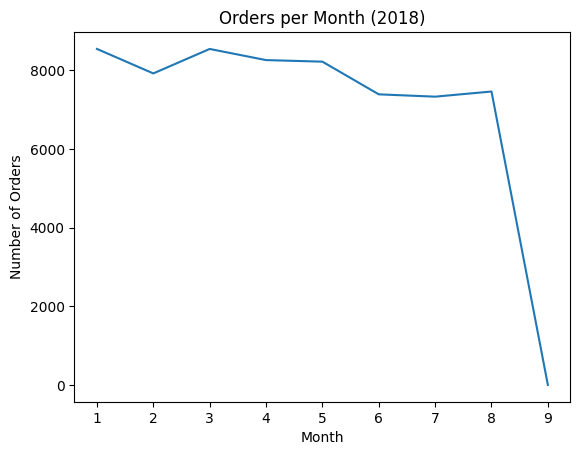

In [6]:
monthly_orders.plot(kind='line')
plt.title("Orders per Month (2018)")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.show()

In [7]:
# 2.Avg Products Per Orders
avg_products = df.groupby(['order_id', 'customer_city']) \
                 .size().reset_index(name='product_count')

avg_products_city = avg_products.groupby('customer_city')['product_count'].mean()

print(avg_products_city.head())

customer_city
abadia dos dourados    1.000000
abadiania              1.000000
abaete                 1.000000
abaetetuba             1.363636
abaiara                1.000000
Name: product_count, dtype: float64


In [10]:
print(df.columns)

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'payment_sequential', 'payment_type', 'payment_installments',
       'payment_value', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value', 'product category',
       'product_name_length', 'product_description_length',
       'product_photos_qty', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state'],
      dtype='object')


product category
bed table bath                 8.539144
HEALTH BEAUTY                  8.264002
computer accessories           7.904782
Furniture Decoration           7.131153
Watches present                7.126367
                                 ...   
PC Gamer                       0.010842
House Comfort 2                0.008529
cds music dvds                 0.005981
Fashion Children's Clothing    0.003918
insurance and services         0.001618
Name: payment_value, Length: 73, dtype: float64


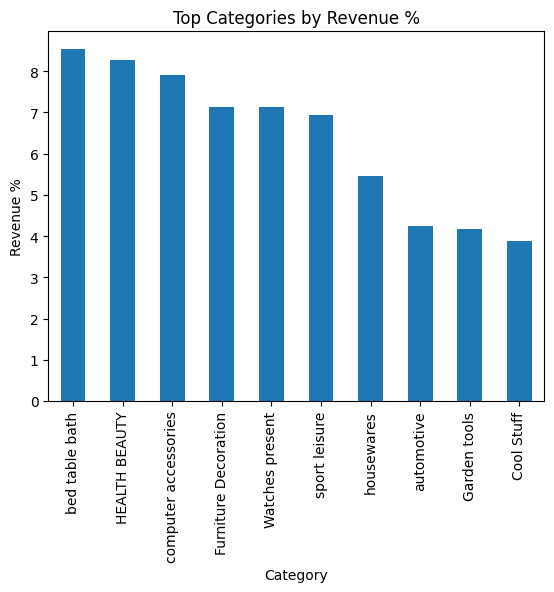

In [13]:
#3. Revenue by category
category_revenue = df.groupby('product category')['payment_value'].sum()

category_percentage = (category_revenue / category_revenue.sum()) * 100

print(category_percentage.sort_values(ascending=False))

category_percentage.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Categories by Revenue %")
plt.xlabel("Category")
plt.ylabel("Revenue ")
plt.show()

Correlation: -0.03214638455278418


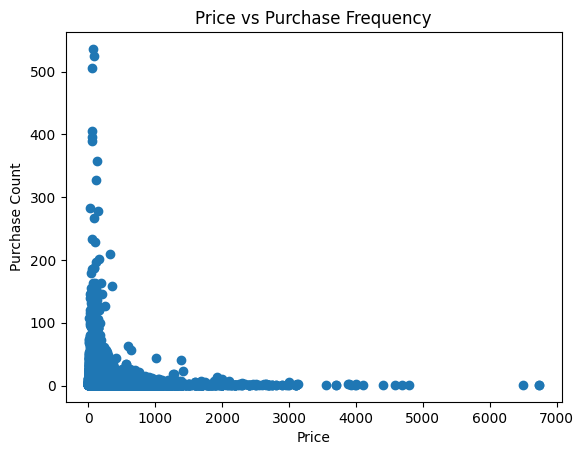

In [15]:
#4. Correlation (Price vs Purchase Count)
corr_df = df.groupby('product_id').agg({
    'price': 'mean',
    'order_id': 'count'
}).rename(columns={'order_id': 'purchase_count'})

correlation = corr_df['price'].corr(corr_df['purchase_count'])

print("Correlation:", correlation)

# Scatter Plot
plt.scatter(corr_df['price'], corr_df['purchase_count'])
plt.xlabel("Price")
plt.ylabel("Purchase Count")
plt.title("Price vs Purchase Frequency")
plt.show()


Advance Analysis

In [16]:
# 1. Moving average

df = df.sort_values(by=['customer_id', 'order_purchase_timestamp'])

df['moving_avg'] = df.groupby('customer_id')['payment_value'] \
                     .rolling(window=3, min_periods=1) \
                     .mean().reset_index(0, drop=True)

print(df[['customer_id', 'payment_value', 'moving_avg']].head())


                            customer_id  payment_value  moving_avg
80946  00012a2ce6f8dcda20d059ce98491703         114.74      114.74
11781  000161a058600d5901f007fab4c27140          67.41       67.41
77773  0001fd6190edaaf884bcaf3d49edf079         195.42      195.42
51067  0002414f95344307404f0ace7a26f1d5         179.35      179.35
6880   000379cdec625522490c315e70c7a9fb         107.01      107.01


   year  month  payment_value  cumulative_sales
0  2016      9         347.52            347.52
1  2016     10       73914.58          74262.10
2  2016     12          19.62          74281.72
3  2017      1      187779.41         187779.41
4  2017      2      344134.79         531914.20


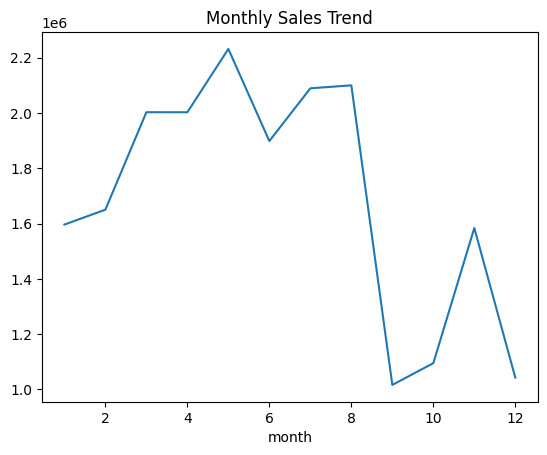

In [17]:
# 2.cumalitive Sales

df['year'] = df['order_purchase_timestamp'].dt.year
df['month'] = df['order_purchase_timestamp'].dt.month

monthly_sales = df.groupby(['year', 'month'])['payment_value'].sum().reset_index()

monthly_sales['cumulative_sales'] = monthly_sales.groupby('year')['payment_value'].cumsum()

print(monthly_sales.head())

monthly_sales.groupby('month')['payment_value'].sum().plot()
plt.title("Monthly Sales Trend")
plt.show()

   year  payment_value  previous_year   growth_rate
0  2016       74281.72            NaN           NaN
1  2017     9160941.90       74281.72  12232.700293
2  2018    11072911.09     9160941.90     20.870880


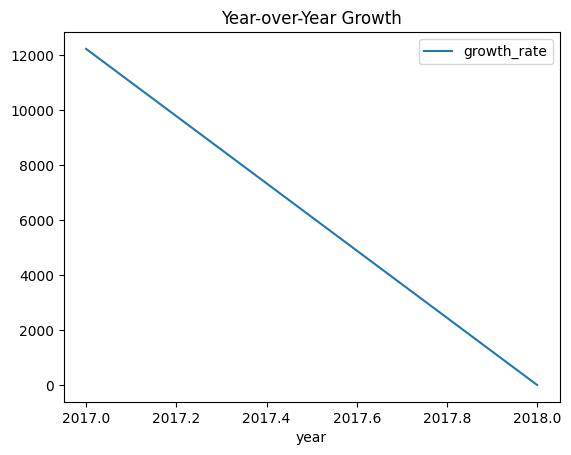

In [18]:
# 3. Year-over-Year Growth
yearly_sales = df.groupby('year')['payment_value'].sum().reset_index()

yearly_sales['previous_year'] = yearly_sales['payment_value'].shift(1)

yearly_sales['growth_rate'] = (
    (yearly_sales['payment_value'] - yearly_sales['previous_year']) /
    yearly_sales['previous_year']
) * 100

print(yearly_sales)

# Visualization
yearly_sales.plot(x='year', y='growth_rate', kind='line')
plt.title("Year-over-Year Growth")
plt.show()

In [20]:
# Top 3 Customers

top_customers = df.groupby(['year', 'customer_id'])['payment_value'].sum().reset_index()

top_customers['rank'] = top_customers.groupby('year')['payment_value'] \
                                     .rank(method='first', ascending=False)

top3 = top_customers[top_customers['rank'] <= 3]

print(top3)

       year                       customer_id  payment_value  rank
91     2016  5263febf1413e9a60ceb7b842008b7ef        2441.52   3.0
123    2016  6b79d5d9914b88e0e05a19e76dfe926b        2707.68   2.0
128    2016  6deeb4ffef6cf320ef5a642302f04104        3751.20   1.0
1239   2017  05455dfa7cd02f13d132aa7a6a9729c6       36489.24   3.0
4155   2017  1617b1357756262bfa56ab541c47bc16      109312.64   1.0
33460  2017  bd5d39761aa56689a265d95d8d32b8be       45256.00   2.0
51570  2018  1ff773612ab8934db89fd5afa8afe506       30186.00   2.0
84965  2018  be1b70680b9f9694d8c70f41fa3dc92b       44048.00   1.0
94591  2018  ec5b2ba62e574342386871631fafd3fc       29099.52   3.0
